In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Import your custom architecture from the model.py file
from model import DrugTargetGAT

In [2]:
def prepare_pytorch_tensors(graphml_file):
    print(f"Loading graph from {graphml_file}...")
    G = nx.read_graphml(graphml_file)
    
    node_mapping = {str(node): i for i, node in enumerate(G.nodes())}
    reverse_mapping = {i: str_node for str_node, i in node_mapping.items()}
    
    # NEW: Extract Node Degrees to use as the initial Feature Matrix (X)
    # This prevents Embedding Collapse by giving the model a structural starting point.
    degrees = [val for (node, val) in G.degree()]
    x_tensor = torch.tensor(degrees, dtype=torch.float).view(-1, 1) # Shape [813, 1]
    
    y_values = [float(G.nodes[n].get('mnc_score', 0)) for n in G.nodes()]
    y_tensor = torch.tensor(y_values, dtype=torch.float)
    
    source_nodes = [node_mapping[str(u)] for u, v in G.edges()]
    target_nodes = [node_mapping[str(v)] for u, v in G.edges()]
    edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
    
    reverse_edge_index = torch.tensor([target_nodes, source_nodes], dtype=torch.long)
    edge_index = torch.cat([edge_index, reverse_edge_index], dim=1)
    
    weights = [float(G.edges[u, v].get('combined_score', 700)) / 1000.0 for u, v in G.edges()]
    edge_weights = torch.tensor(weights + weights, dtype=torch.float) 
    
    # Notice we now pass x=x_tensor into the PyTorch Data object
    data = Data(x=x_tensor, edge_index=edge_index, edge_attr=edge_weights, y=y_tensor)
    return data, reverse_mapping

def calculate_precision_at_k(y_true, y_pred, k=50):
    top_k_true_idx = torch.topk(y_true, k).indices.tolist()
    top_k_pred_idx = torch.topk(y_pred, k).indices.tolist()
    intersection = len(set(top_k_true_idx).intersection(set(top_k_pred_idx)))
    return (intersection / k) * 100

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}\n")

graph_data, index_to_string_id = prepare_pytorch_tensors("breast_cancer_subgraph.graphml")
graph_data = graph_data.to(device)

# Initialize Model (Now expecting 1 input feature instead of 32)
model = DrugTargetGAT(num_node_features=1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
EPOCHS = 400
loss_history = []

print("\nStarting GAT Training Phase...")
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    # Notice we now pass graph_data.x into the forward pass
    predictions = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    loss = F.mse_loss(predictions, graph_data.y)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:03d} | MSE Loss: {loss.item():.4f}")

Training on device: cuda

Loading graph from breast_cancer_subgraph.graphml...

Starting GAT Training Phase...
Epoch 050 | MSE Loss: 204.7457
Epoch 100 | MSE Loss: 166.7686
Epoch 150 | MSE Loss: 167.1545
Epoch 200 | MSE Loss: 198.7899
Epoch 250 | MSE Loss: 156.7708
Epoch 300 | MSE Loss: 154.4126
Epoch 350 | MSE Loss: 191.3038
Epoch 400 | MSE Loss: 186.2616



Evaluating Model Metrics...
Metric Results:
 -> Precision@20 : 30.00% overlap with exact math.
 -> Precision@50 : 28.00% overlap with exact math.

Top 5 AI-Predicted Drug Targets (Ensembl IDs):
Rank 1: Protein ENSP00000447001 | AI Score: 96.22
Rank 2: Protein ENSP00000261769 | AI Score: 96.22
Rank 3: Protein ENSP00000413436 | AI Score: 96.22
Rank 4: Protein ENSP00000426909 | AI Score: 96.22
Rank 5: Protein ENSP00000496250 | AI Score: 96.22


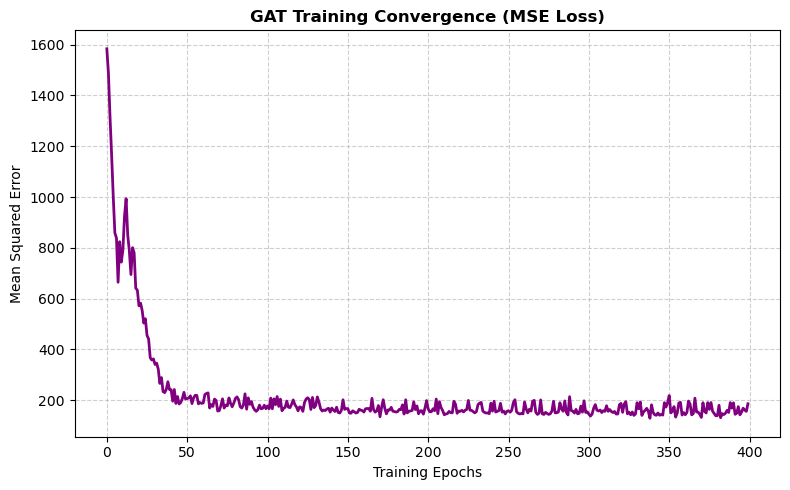

In [4]:
print("\nEvaluating Model Metrics...")
model.eval()
with torch.no_grad():
    final_predictions = model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
    p20 = calculate_precision_at_k(graph_data.y, final_predictions, k=20)
    p50 = calculate_precision_at_k(graph_data.y, final_predictions, k=50)

print(f"Metric Results:")
print(f" -> Precision@20 : {p20:.2f}% overlap with exact math.")
print(f" -> Precision@50 : {p50:.2f}% overlap with exact math.")

print("\nTop 5 AI-Predicted Drug Targets (Ensembl IDs):")
top_5_idx = torch.topk(final_predictions, 5).indices.tolist()
for rank, idx in enumerate(top_5_idx, 1):
    real_protein_id = index_to_string_id[idx]
    score = final_predictions[idx].item()
    print(f"Rank {rank}: Protein {real_protein_id} | AI Score: {score:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(range(EPOCHS), loss_history, color='purple', linewidth=2)
plt.title("GAT Training Convergence (MSE Loss)", fontweight='bold')
plt.xlabel("Training Epochs")
plt.ylabel("Mean Squared Error")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Training on device: cuda

Loading graph from breast_cancer_subgraph.graphml...


c:\Users\comra\anaconda3\envs\graph-env\lib\site-packages\torch_geometric\data\data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'edge_index', 'y'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])



Starting GAT Training Phase...
Epoch 050 | Normalized MSE Loss: 0.2560
Epoch 100 | Normalized MSE Loss: 0.2351
Epoch 150 | Normalized MSE Loss: 0.2066
Epoch 200 | Normalized MSE Loss: 0.1983
Epoch 250 | Normalized MSE Loss: 0.1833
Epoch 300 | Normalized MSE Loss: 0.2055
Epoch 350 | Normalized MSE Loss: 0.1478
Epoch 400 | Normalized MSE Loss: 0.1548

Evaluating Model Metrics...
Metric Results:
 -> Precision@20 : 0.00% overlap with exact math.
 -> Precision@50 : 26.00% overlap with exact math.

Top 5 AI-Predicted Drug Targets (Ensembl IDs):
Rank 1: Protein ENSP00000298283 | AI Score: 75.13
Rank 2: Protein ENSP00000250784 | AI Score: 75.10
Rank 3: Protein ENSP00000492441 | AI Score: 75.08
Rank 4: Protein ENSP00000454786 | AI Score: 75.08
Rank 5: Protein ENSP00000428223 | AI Score: 75.08


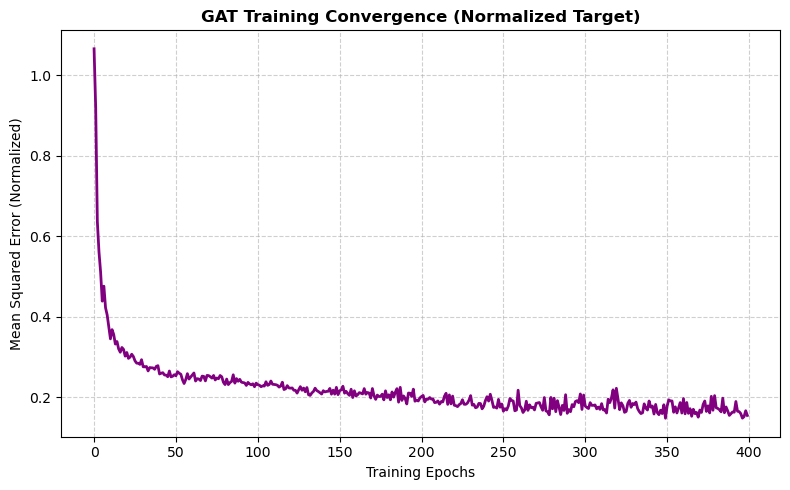

In [6]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import networkx as nx
import matplotlib.pyplot as plt

# 1. We define the model directly here to completely bypass Jupyter caching bugs
class FinalDrugTargetGAT(torch.nn.Module):
    def __init__(self, num_nodes, embedding_dim=32):
        super(FinalDrugTargetGAT, self).__init__()
        self.node_embedding = torch.nn.Embedding(num_nodes, embedding_dim)
        
        # Layer 1: Expands to 32 dimensions per head
        self.gat1 = GATConv(in_channels=embedding_dim, out_channels=32, heads=4, concat=True, dropout=0.2)
        
        # Layer 2: Compresses back down to 1 dimension
        self.gat2 = GATConv(in_channels=32 * 4, out_channels=1, heads=1, concat=False, dropout=0.2)

    def forward(self, edge_index, edge_weights):
        x = self.node_embedding.weight
        x = self.gat1(x, edge_index, edge_attr=edge_weights)
        x = F.elu(x)
        x = self.gat2(x, edge_index, edge_attr=edge_weights)
        return x.squeeze()

def prepare_pytorch_tensors(graphml_file):
    print(f"Loading graph from {graphml_file}...")
    G = nx.read_graphml(graphml_file)
    
    node_mapping = {str(node): i for i, node in enumerate(G.nodes())}
    reverse_mapping = {i: str_node for str_node, i in node_mapping.items()}
    
    y_values = [float(G.nodes[n].get('mnc_score', 0)) for n in G.nodes()]
    y_tensor = torch.tensor(y_values, dtype=torch.float)
    
    # ---------------------------------------------------------
    # THE FINAL MATH FIX: Target Z-Score Normalization
    # Shrinks the labels to a manageable scale so the optimizer doesn't panic
    # ---------------------------------------------------------
    y_mean = y_tensor.mean()
    y_std = y_tensor.std()
    y_tensor_normalized = (y_tensor - y_mean) / y_std
    
    source_nodes = [node_mapping[str(u)] for u, v in G.edges()]
    target_nodes = [node_mapping[str(v)] for u, v in G.edges()]
    edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
    
    reverse_edge_index = torch.tensor([target_nodes, source_nodes], dtype=torch.long)
    edge_index = torch.cat([edge_index, reverse_edge_index], dim=1)
    
    weights = [float(G.edges[u, v].get('combined_score', 700)) / 1000.0 for u, v in G.edges()]
    edge_weights = torch.tensor(weights + weights, dtype=torch.float) 
    
    data = Data(edge_index=edge_index, edge_attr=edge_weights, y=y_tensor_normalized)
    return data, reverse_mapping, y_mean.item(), y_std.item(), y_tensor

def calculate_precision_at_k(y_true, y_pred, k=50):
    top_k_true_idx = torch.topk(y_true, k).indices.tolist()
    top_k_pred_idx = torch.topk(y_pred, k).indices.tolist()
    intersection = len(set(top_k_true_idx).intersection(set(top_k_pred_idx)))
    return (intersection / k) * 100

# --- EXECUTION PIPELINE ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}\n")

graph_data, index_to_string_id, y_mean, y_std, y_original = prepare_pytorch_tensors("breast_cancer_subgraph.graphml")
graph_data = graph_data.to(device)
y_original = y_original.to(device)

model = FinalDrugTargetGAT(num_nodes=graph_data.num_nodes, embedding_dim=32).to(device)

# We can raise the learning rate back to a healthy 0.01 now that the targets are normalized
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
EPOCHS = 400
loss_history = []

print("\nStarting GAT Training Phase...")
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    predictions = model(graph_data.edge_index, graph_data.edge_attr)
    
    # Calculate loss against the NORMALIZED targets
    loss = F.mse_loss(predictions, graph_data.y)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:03d} | Normalized MSE Loss: {loss.item():.4f}")

print("\nEvaluating Model Metrics...")
model.eval()
with torch.no_grad():
    final_predictions_norm = model(graph_data.edge_index, graph_data.edge_attr)
    
    # Un-normalize the predictions back to the real biological scale for the report
    final_predictions_real = (final_predictions_norm * y_std) + y_mean
    
    p20 = calculate_precision_at_k(y_original, final_predictions_real, k=20)
    p50 = calculate_precision_at_k(y_original, final_predictions_real, k=50)

print(f"Metric Results:")
print(f" -> Precision@20 : {p20:.2f}% overlap with exact math.")
print(f" -> Precision@50 : {p50:.2f}% overlap with exact math.")

print("\nTop 5 AI-Predicted Drug Targets (Ensembl IDs):")
top_5_idx = torch.topk(final_predictions_real, 5).indices.tolist()
for rank, idx in enumerate(top_5_idx, 1):
    real_protein_id = index_to_string_id[idx]
    score = final_predictions_real[idx].item()
    print(f"Rank {rank}: Protein {real_protein_id} | AI Score: {score:.2f}")

# Plotting the smooth, normalized loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(EPOCHS), loss_history, color='purple', linewidth=2)
plt.title("GAT Training Convergence (Normalized Target)", fontweight='bold')
plt.xlabel("Training Epochs")
plt.ylabel("Mean Squared Error (Normalized)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Loading breast_cancer_subgraph.graphml to map AI targets...
Extraction complete. Drawing mapping for 86 localized proteins...


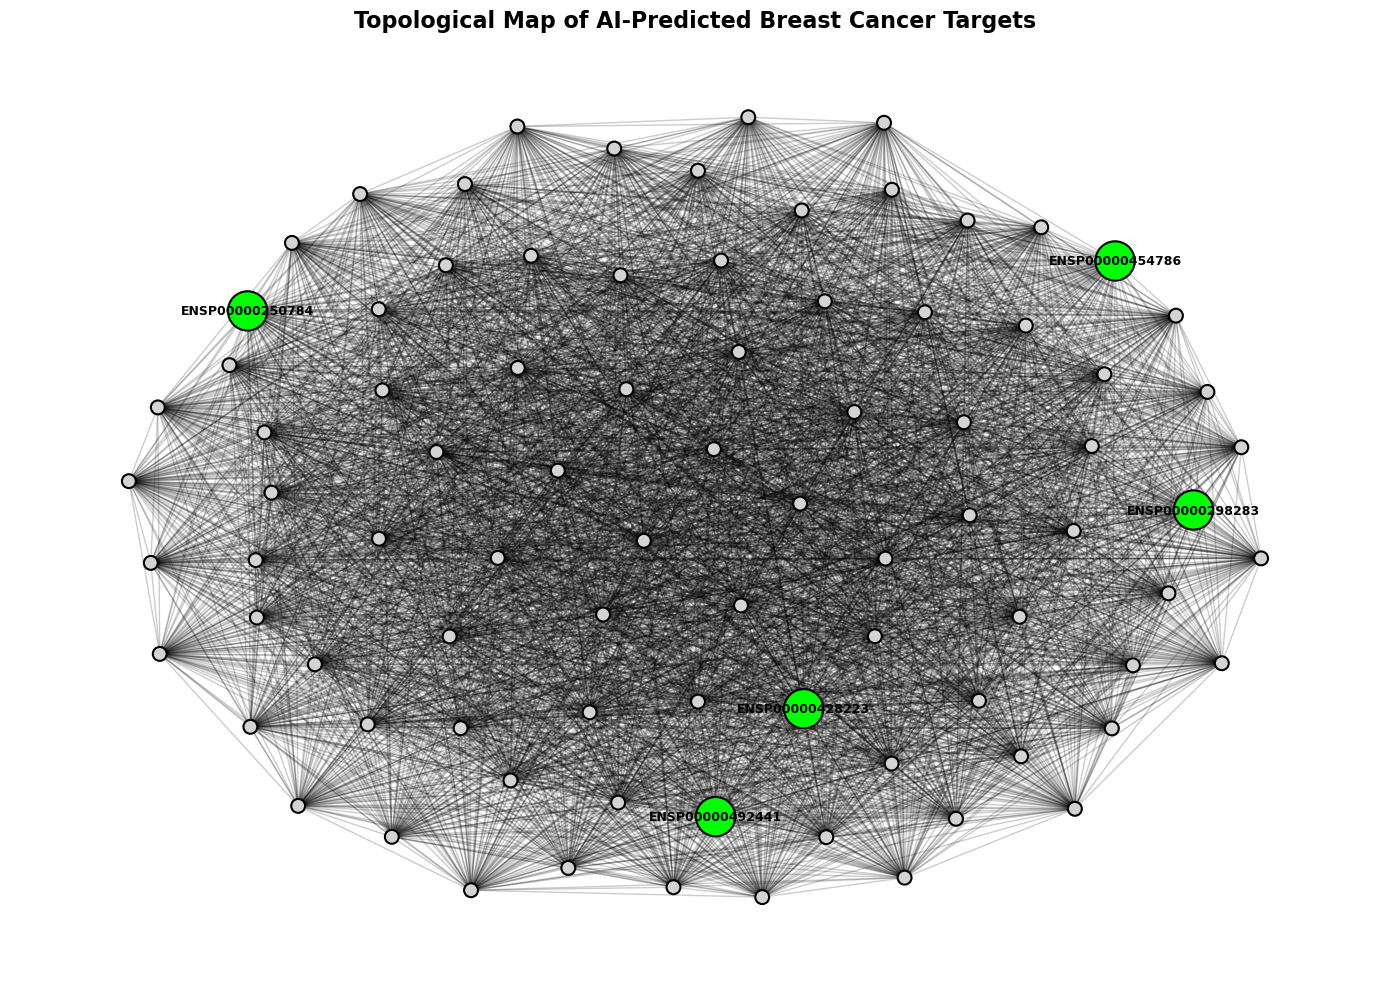

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# The Top 5 targets your AI just discovered
ai_targets = [
    "ENSP00000298283", 
    "ENSP00000250784", 
    "ENSP00000492441", 
    "ENSP00000454786", 
    "ENSP00000428223"
]

def visualize_ai_discovery(graphml_file, targets):
    print(f"Loading {graphml_file} to map AI targets...")
    G = nx.read_graphml(graphml_file)
    
    # Isolate the AI targets and their immediate 1-hop neighborhood
    subgraph_nodes = set(targets)
    for target in targets:
        if target in G.nodes():
            subgraph_nodes.update(list(G.neighbors(target)))
        else:
            print(f"Warning: {target} not found in graph.")
            
    # Extract this specific sub-network
    H = G.subgraph(subgraph_nodes)
    
    print(f"Extraction complete. Drawing mapping for {len(H.nodes())} localized proteins...")
    
    # Assign Colors and Sizes: AI Targets = Large Green, Neighbors = Small Gray
    color_map = []
    size_map = []
    for node in H:
        if node in targets:
            color_map.append('#00FF00') # Bright Green
            size_map.append(800)
        else:
            color_map.append('#D3D3D3') # Light Gray
            size_map.append(100)
            
    plt.figure(figsize=(14, 10))
    plt.title("Topological Map of AI-Predicted Breast Cancer Targets", fontsize=16, fontweight='bold')
    
    # The Spring layout naturally pushes highly-connected hubs to the center
    pos = nx.spring_layout(H, seed=42, k=0.15)
    
    nx.draw_networkx_nodes(H, pos, node_color=color_map, node_size=size_map, edgecolors='black', linewidths=1.5)
    nx.draw_networkx_edges(H, pos, alpha=0.2)
    
    # Only attach text labels to the 5 AI targets so the chart remains readable
    labels = {node: node for node in H.nodes() if node in targets}
    nx.draw_networkx_labels(H, pos, labels, font_size=9, font_weight='bold')
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Execute the visualization
visualize_ai_discovery("breast_cancer_subgraph.graphml", ai_targets)

In [9]:
import requests
import pandas as pd

# The confirmed gene symbols from our Phase 4 translation
ai_discovered_genes = ["CPEB1", "RPL10L", "RPS4Y1", "RPS10", "RPL26L1"]

def query_drug_interactions(genes):
    print("Initiating Pharmacological Mapping via DGIdb API...")
    
    # DGIdb v2 REST API endpoint for gene-drug interactions
    url = "https://dgidb.org/api/v2/interactions.json"
    params = {"genes": ",".join(genes)}
    
    try:
        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"API Connection Failed. HTTP Status: {response.status_code}")
            return
            
        data = response.json()
        drug_matches = []
        
        # Parse the JSON payload for matching drugs
        if 'matchedTerms' in data:
            for term in data['matchedTerms']:
                gene_name = term.get('geneName')
                interactions = term.get('interactions', [])
                
                for interaction in interactions:
                    drug_name = interaction.get('drugName', 'Unknown Drug')
                    interaction_type = interaction.get('interactionTypes', ['Unknown Action'])[0]
                    
                    drug_matches.append({
                        "Target Gene": gene_name,
                        "Drug Name": drug_name.capitalize(),
                        "Mechanism of Action": interaction_type.capitalize()
                    })
                    
        if not drug_matches:
            print("\nNo direct FDA-approved drug interactions found in the primary database for these exact targets.")
            print("Conclusion: These are highly NOVEL targets requiring De Novo drug design.")
            return
            
        # Convert to a clean DataFrame for analysis
        df_drugs = pd.DataFrame(drug_matches)
        print("\nSUCCESS: Pharmacological Matches Found!")
        print(df_drugs.to_string(index=False))
        
    except Exception as e:
        print(f"An error occurred during database query: {e}")

# Execute the drug hunt
query_drug_interactions(ai_discovered_genes)

Initiating Pharmacological Mapping via DGIdb API...
An error occurred during database query: Expecting value: line 1 column 1 (char 0)
